# Casting Defect Detection with OpenCV

Goal:
Detect possible defects in casting images using classical image processing.

Pipeline:

Image → Grayscale → CLAHE → Blur → Thresholding →
Morphology → Canny → Contours → Bounding Boxes →
Good / Defective Decision

Import libraries

In [1]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

Download Dataset: Casting defect = a crack, hole, spot, or other defect in the manufactured metal part.

In [2]:
!pip install -q kagglehub


[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import kagglehub

path = kagglehub.dataset_download(
    "ravirajsinh45/real-life-industrial-dataset-of-casting-product"
)

print("Dataset path:", path)

c:\Users\pegah\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


100%|██████████| 100M/100M [00:02<00:00, 38.2MB/s] 

Extracting files...


Dataset path: C:\Users\pegah\.cache\kagglehub\datasets\ravirajsinh45\real-life-industrial-dataset-of-casting-product\versions\2


Dataset Paths

In [4]:
train_good = os.path.join(
    path, "casting_data/casting_data/train/ok_front"
)

train_def = os.path.join(
    path, "casting_data/casting_data/train/def_front"
)

test_good = os.path.join(
    path, "casting_data/casting_data/test/ok_front"
)

test_def = os.path.join(
    path, "casting_data/casting_data/test/def_front"
)

print("Train Good:", len(os.listdir(train_good)))
print("Train Defective:", len(os.listdir(train_def)))

print("Test Good:", len(os.listdir(test_good)))
print("Test Defective:", len(os.listdir(test_def)))

Train Good: 2875
Train Defective: 3758
Test Good: 262
Test Defective: 453


Explore Images

Load one Good and one Defective image

In [5]:
good_file = os.listdir(train_good)[0]
def_file = os.listdir(train_def)[0]

good_path = os.path.join(train_good, good_file)
def_path = os.path.join(train_def, def_file)

good_img = cv2.imread(good_path)
def_img = cv2.imread(def_path)

Show Good vs Defective

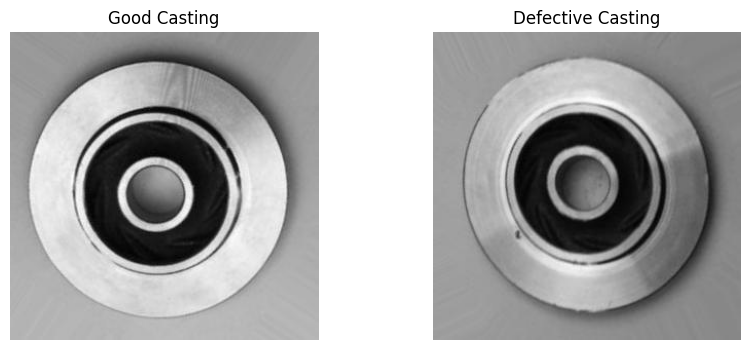

In [6]:
good_rgb = cv2.cvtColor(good_img, cv2.COLOR_BGR2RGB)
def_rgb = cv2.cvtColor(def_img, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(good_rgb)
plt.title("Good Casting")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(def_rgb)
plt.title("Defective Casting")
plt.axis("off")

plt.show()

Grayscale

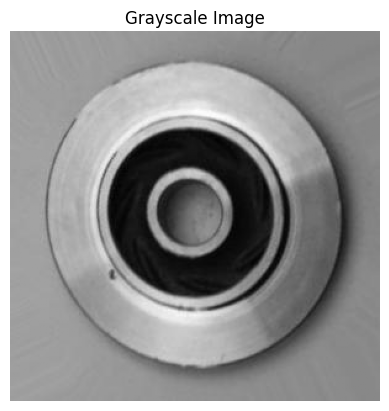

In [7]:
gray = cv2.cvtColor(def_img, cv2.COLOR_BGR2GRAY)

plt.imshow(gray, cmap="gray")
plt.title("Grayscale Image")
plt.axis("off")
plt.show()

CLAHE

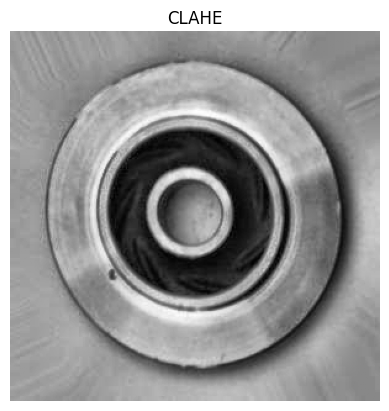

In [8]:
clahe = cv2.createCLAHE(
    clipLimit=2.0,
    tileGridSize=(8, 8)
)

enhanced = clahe.apply(gray)

plt.imshow(enhanced, cmap="gray")
plt.title("CLAHE")
plt.axis("off")
plt.show()

Gaussian Blur

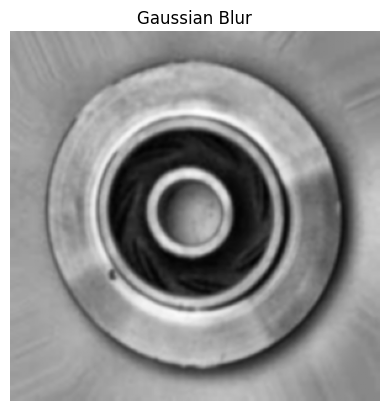

In [9]:
gaussian = cv2.GaussianBlur(
    enhanced,
    (5, 5),
    0
)

plt.imshow(gaussian, cmap="gray")
plt.title("Gaussian Blur")
plt.axis("off")
plt.show()

Median Blur

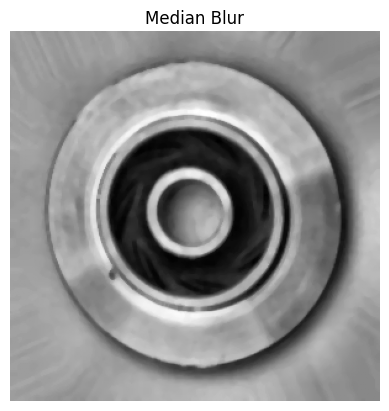

In [10]:
median = cv2.medianBlur(
    enhanced,
    5
)

plt.imshow(median, cmap="gray")
plt.title("Median Blur")
plt.axis("off")
plt.show()

Gaussian → smooth general noise
Median → good for salt-and-pepper noise

### Black Hat Morphology

Black Hat highlights small dark regions on a bright background.
This can help reveal dark casting defects.

Black Hat Morphology highlights small dark regions on a bright background.

Formula:

Black Hat = Closing - Original Image

It is useful for detecting dark defects, spots, or cracks.

In the output:
bright/white areas = dark regions detected in the original image.

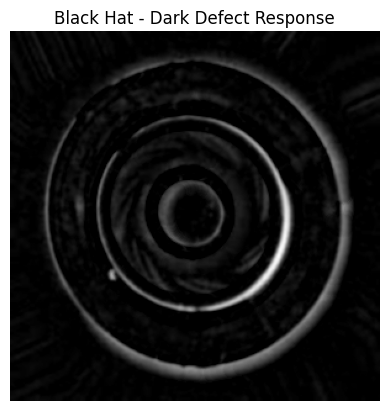

In [11]:
kernel = cv2.getStructuringElement(
    cv2.MORPH_ELLIPSE,
    (15, 15)
)

blackhat = cv2.morphologyEx(
    gaussian,
    cv2.MORPH_BLACKHAT,
    kernel
)

plt.imshow(blackhat, cmap="gray")
plt.title("Black Hat - Dark Defect Response")
plt.axis("off")
plt.show()

Create a circular ROI

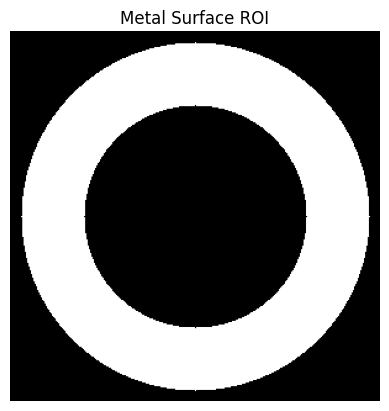

In [12]:
h, w = gray.shape
center = (w // 2, h // 2)

inner_radius = int(min(h, w) * 0.30)
outer_radius = int(min(h, w) * 0.47)

roi_mask = np.zeros_like(gray)

# Outer circle
cv2.circle(roi_mask, center, outer_radius, 255, -1)

# Remove inner circle
cv2.circle(roi_mask, center, inner_radius, 0, -1)

plt.imshow(roi_mask, cmap="gray")
plt.title("Metal Surface ROI")
plt.axis("off")
plt.show()

Black Hat only inside ROI

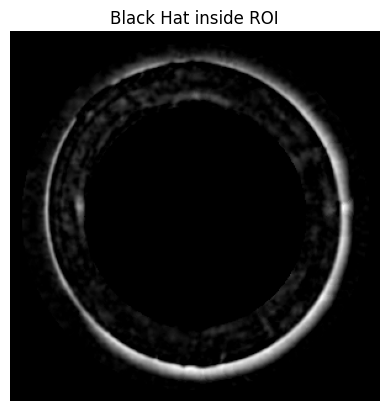

In [13]:
roi_blackhat = cv2.bitwise_and(
    blackhat,
    blackhat,
    mask=roi_mask
)

plt.imshow(roi_blackhat, cmap="gray")
plt.title("Black Hat inside ROI")
plt.axis("off")
plt.show()

Otsu Threshold

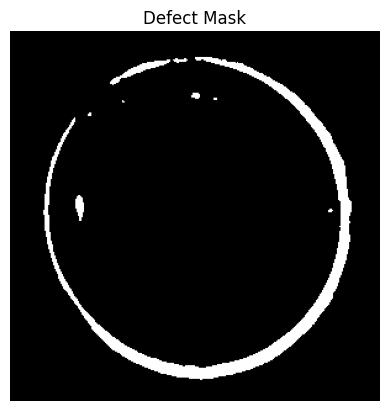

In [14]:
_, binary = cv2.threshold(
    roi_blackhat,
    0,
    255,
    cv2.THRESH_BINARY + cv2.THRESH_OTSU
)

plt.imshow(binary, cmap="gray")
plt.title("Defect Mask")
plt.axis("off")
plt.show()

Opening to remove small noise

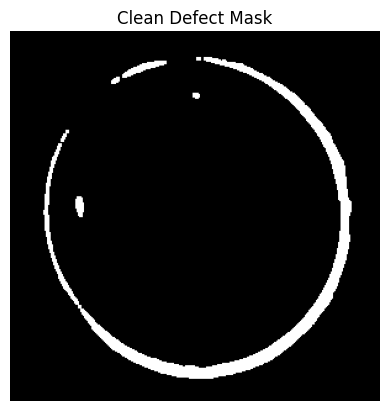

In [15]:
kernel_small = np.ones((3, 3), np.uint8)

clean = cv2.morphologyEx(
    binary,
    cv2.MORPH_OPEN,
    kernel_small
)

plt.imshow(clean, cmap="gray")
plt.title("Clean Defect Mask")
plt.axis("off")
plt.show()

Contours

In [16]:
contours, _ = cv2.findContours(
    clean,
    cv2.RETR_EXTERNAL,
    cv2.CHAIN_APPROX_SIMPLE
)

print("Contours:", len(contours))

Contours: 7


Keep only small defects

In [17]:
defect_contours = []

for c in contours:
    area = cv2.contourArea(c)
    x, y, w, h = cv2.boundingRect(c)

    if 20 < area < 500 and w < 50 and h < 50:
        defect_contours.append(c)

print("Possible defects:", len(defect_contours))

Possible defects: 3


Print the feature of each contour

In [18]:

for i, c in enumerate(contours):
    area = cv2.contourArea(c)
    x, y, w, h = cv2.boundingRect(c)
    peri = cv2.arcLength(c, True)

    if peri == 0:
        continue

    circularity = 4 * np.pi * area / (peri * peri)
    aspect_ratio = w / float(h)

    print(
        f"Contour {i}: area={area:.1f}, w={w}, h={h}, "
        f"aspect_ratio={aspect_ratio:.2f}, circularity={circularity:.2f}"
    )

Contour 0: area=75.5, w=7, h=17, aspect_ratio=0.41, circularity=0.60
Contour 1: area=19.0, w=7, h=10, aspect_ratio=0.70, circularity=0.34
Contour 2: area=17.5, w=6, h=5, aspect_ratio=1.20, circularity=0.83
Contour 3: area=21.5, w=7, h=6, aspect_ratio=1.17, circularity=0.74
Contour 4: area=150.0, w=36, h=14, aspect_ratio=2.57, circularity=0.27
Contour 5: area=4119.5, w=250, h=261, aspect_ratio=0.96, circularity=0.03
Contour 6: area=6.0, w=4, h=3, aspect_ratio=1.33, circularity=0.75


show the contour numbers on the image.

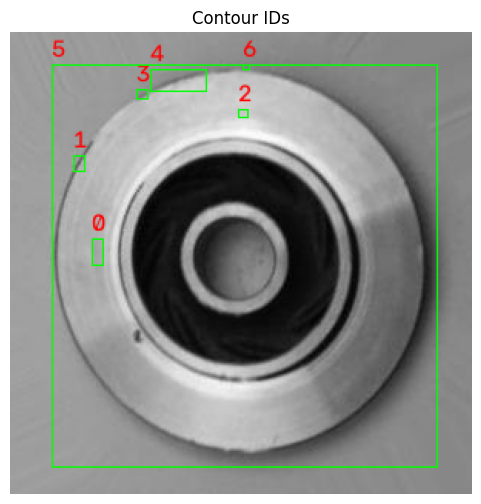

In [19]:
label_img = def_img.copy()

for i, c in enumerate(contours):
    x, y, w, h = cv2.boundingRect(c)
    cv2.rectangle(label_img, (x, y), (x+w, y+h), (0, 255, 0), 1)
    cv2.putText(
        label_img,
        str(i),
        (x, y-5),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.5,
        (0, 0, 255),
        1
    )

plt.figure(figsize=(6,6))
plt.imshow(cv2.cvtColor(label_img, cv2.COLOR_BGR2RGB))
plt.title("Contour IDs")
plt.axis("off")
plt.show()

In [20]:
candidates = []

for i, c in enumerate(contours):

    area = cv2.contourArea(c)
    x, y, w, h = cv2.boundingRect(c)

    # remove tiny regions and huge ROI boundary
    if 20 < area < 500 and w < 50 and h < 50:

        mask = np.zeros_like(roi_blackhat)
        cv2.drawContours(mask, [c], -1, 255, -1)

        mean_response = cv2.mean(
            roi_blackhat,
            mask=mask
        )[0]

        candidates.append((i, c, mean_response))

        print(
            f"Contour {i}: "
            f"area={area:.1f}, "
            f"blackhat={mean_response:.1f}"
        )

Contour 0: area=75.5, blackhat=38.6
Contour 3: area=21.5, blackhat=36.4
Contour 4: area=150.0, blackhat=40.3


Then keep only the right candidates.

In [21]:
best = max(candidates, key=lambda x: x[2])

best_id, best_contour, score = best

print("Best contour:", best_id)
print("Score:", score)

Best contour: 4
Score: 40.3031914893617


Final Result

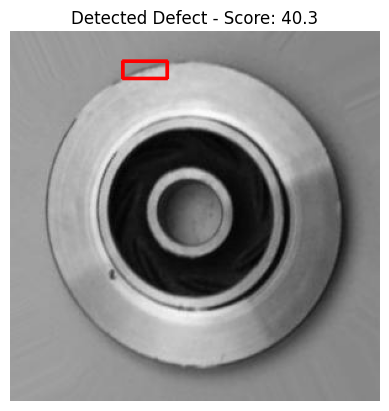

In [22]:
result = def_img.copy()

x, y, w, h = cv2.boundingRect(best_contour)

cv2.rectangle(
    result,
    (x, y),
    (x + w, y + h),
    (0, 0, 255),
    2
)

plt.imshow(cv2.cvtColor(result, cv2.COLOR_BGR2RGB))
plt.title(f"Detected Defect - Score: {score:.1f}")
plt.axis("off")
plt.show()

pipeline view

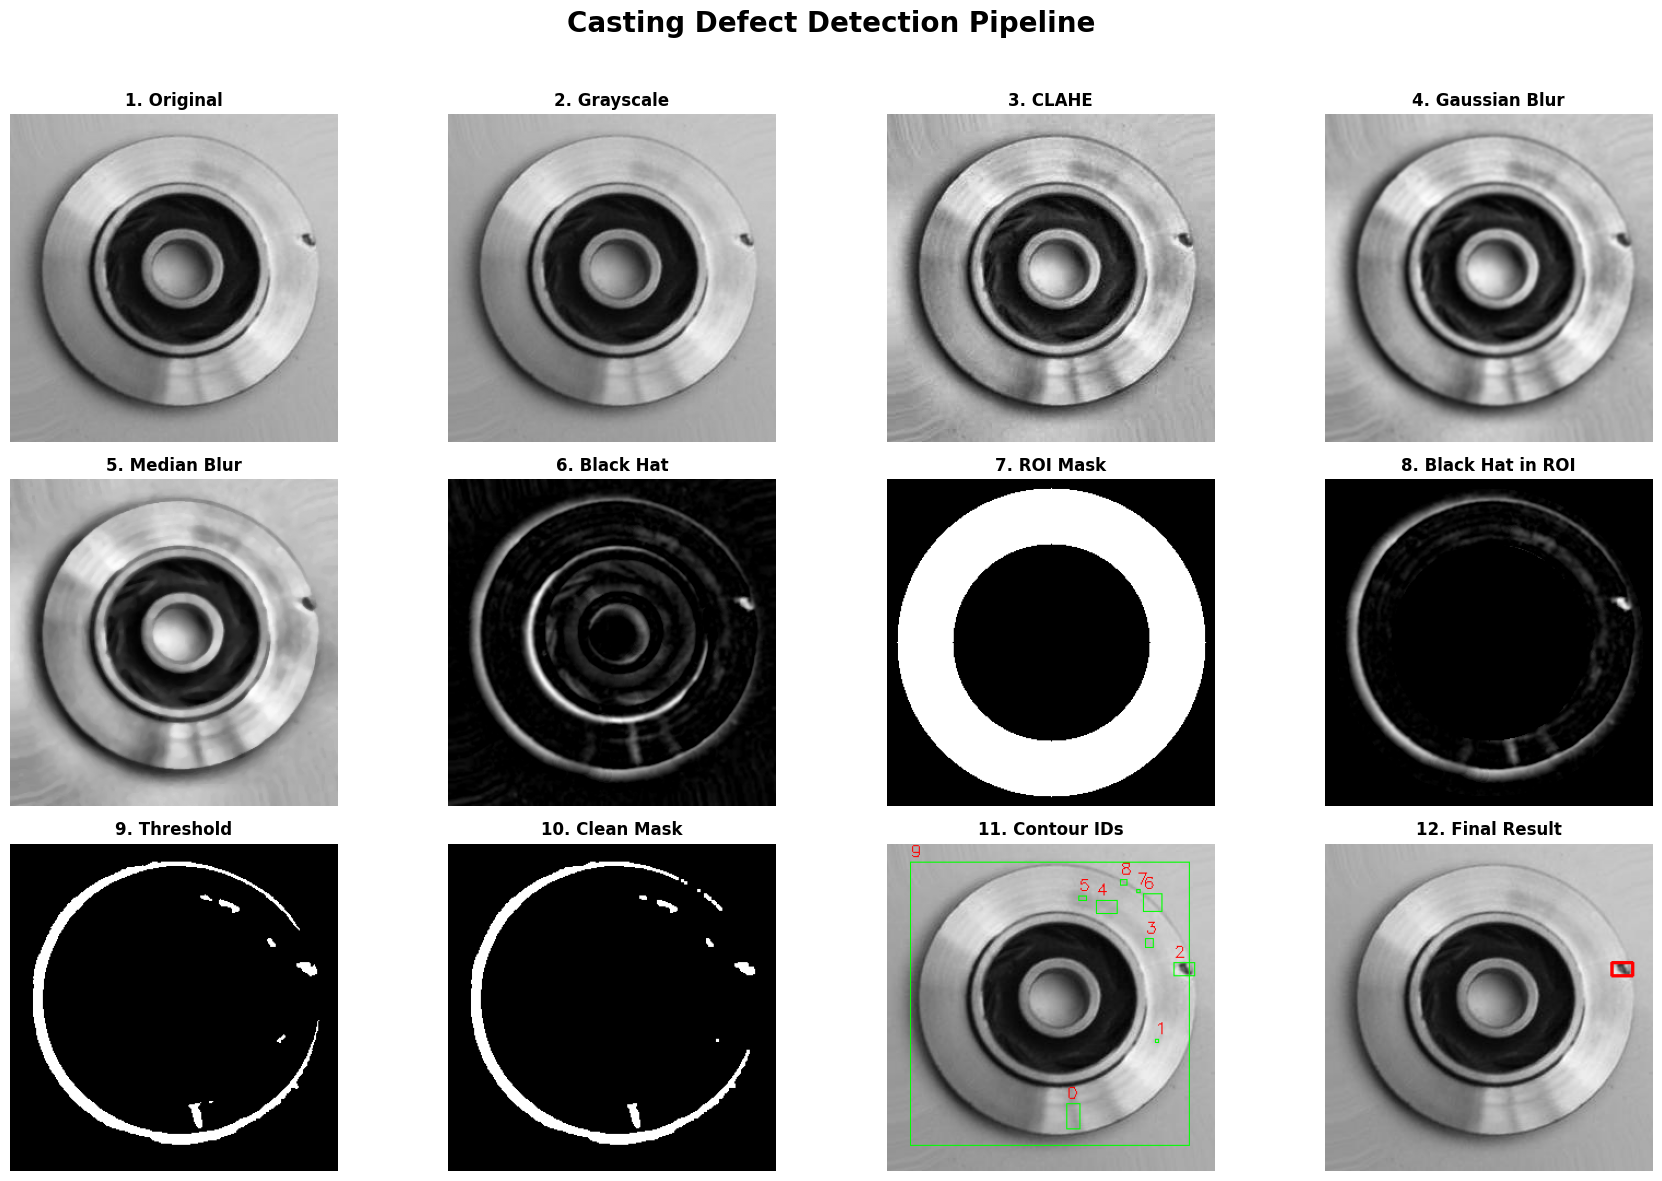

In [58]:
import matplotlib.pyplot as plt
import cv2

# Convert BGR images to RGB if needed
result_rgb = cv2.cvtColor(result, cv2.COLOR_BGR2RGB)
label_img_rgb = cv2.cvtColor(label_img, cv2.COLOR_BGR2RGB)

# If def_rgb is not already defined, uncomment this:
# def_rgb = cv2.cvtColor(def_img, cv2.COLOR_BGR2RGB)

steps = [
    ("1. Original", def_rgb),
    ("2. Grayscale", gray),
    ("3. CLAHE", enhanced),
    ("4. Gaussian Blur", gaussian),

    ("5. Median Blur", median),
    ("6. Black Hat", blackhat),
    ("7. ROI Mask", roi_mask),
    ("8. Black Hat in ROI", roi_blackhat),

    ("9. Threshold", binary),
    ("10. Clean Mask", clean),
    ("11. Contour IDs", label_img_rgb),
    ("12. Final Result", result_rgb)
]

cols = 4
rows = (len(steps) + cols - 1) // cols

fig = plt.figure(figsize=(18, 12))
fig.suptitle("Casting Defect Detection Pipeline", fontsize=20, fontweight="bold")

for i, (title, img) in enumerate(steps, 1):
    ax = plt.subplot(rows, cols, i)

    if len(img.shape) == 2:
        ax.imshow(img, cmap="gray")
    else:
        ax.imshow(img)

    ax.set_title(title, fontsize=12, fontweight="bold")
    ax.axis("off")

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

## Image Fundamentals

Practice image shape, channels, pixel access, resizing, cropping, and saving.

In [ ]:
import sys
from pathlib import Path

# Allow notebook to import code from src/
project_root = Path.cwd()

if project_root.name == "notebooks":
    project_root = project_root.parent

sys.path.insert(0, str(project_root))

from src.image_fundamentals import (
    get_image_info,
    resize_image,
    crop_image,
    save_image
)

In [ ]:
height, width, channels = get_image_info(def_img)

print("Height:", height)
print("Width:", width)
print("Channels:", channels)

In [ ]:
pixel = def_img[100, 100]

print("Pixel value (BGR):", pixel)

In [ ]:
resized = resize_image(def_img, 300, 300)

plt.imshow(cv2.cvtColor(resized, cv2.COLOR_BGR2RGB))
plt.title("Resized Image")
plt.axis("off")
plt.show()

In [ ]:
cropped = crop_image(def_img, 100, 100, 250, 250)

plt.imshow(cv2.cvtColor(cropped, cv2.COLOR_BGR2RGB))
plt.title("Cropped Image")
plt.axis("off")
plt.show()

In [ ]:
save_image(cropped, "cropped_casting.jpg")
print("Image saved successfully.")